# AISI — AI Supremacy Index: Scoring Pipeline
### v3 Methodology | All 5 Datasets → 7 Dimensions → Final Score

This notebook implements the full AISI scoring pipeline:
1. Load all master datasets
2. Harmonize country names across datasets
3. Compute 7 dimension scores
4. Apply coverage-weighted composite
5. Generate final rankings with confidence flags

---

## 1. Setup & Configuration

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#0D1117',
    'text.color': '#C9D1D9', 'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E', 'ytick.color': '#8B949E',
    'axes.edgecolor': '#21262D', 'grid.color': '#21262D', 'grid.alpha': 0.6,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'figure.dpi': 120,
})
C = {
    'accent': '#58A6FF', 'accent2': '#3FB950', 'accent3': '#D29922',
    'accent4': '#F778BA', 'accent5': '#BC8CFF', 'danger': '#F85149',
    'muted': '#484F58', 'bg': '#0D1117', 'surface': '#161B22',
    'border': '#21262D', 'text': '#C9D1D9', 'text_dim': '#8B949E',
    'cyan': '#39D2C0', 'orange': '#F97316',
}

OUT = '/Users/shadowclone/Documents/aisi/aisi/'

# ── AISI Dimension Weights (v3) ──
WEIGHTS = {
    'research_capacity': 0.20,
    'innovation_output': 0.15,
    'commercial_ecosystem': 0.20,
    'hardware_sovereignty': 0.25,
    'collaboration_network': 0.05,
    'talent_base': 0.10,
    'governance_readiness': 0.05,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'

# ── Group entities to exclude ──
GROUP_ENTITIES = {
    'ASEAN', 'Africa', 'Asia', 'EU', 'Europe', 'Five Eyes',
    'Global Partnership on Artificial Intelligence', 'NATO',
    'North America and the Caribbean', 'OECD', 'Oceania', 'Quad',
    'Sub-Saharan Africa', 'G7', 'G20', 'MIKTA', 'Latin America',
}

# ── Strategic collaboration topic multipliers ──
TOPIC_MULTIPLIERS = {
    'Chip design and fabrication': 2.0,
    'Large language models': 1.8,
    'AI safety': 1.6,
    'Cybersecurity': 1.4,
    'Natural language processing': 1.2,
    'Artificial intelligence': 1.2,
    'Computer vision': 1.0,
    'Robotics': 1.0,
}

print('Setup complete ✓')
print(f'Dimension weights: {WEIGHTS}')
print(f'Sum: {sum(WEIGHTS.values())}')

Setup complete ✓
Dimension weights: {'research_capacity': 0.2, 'innovation_output': 0.15, 'commercial_ecosystem': 0.2, 'hardware_sovereignty': 0.25, 'collaboration_network': 0.05, 'talent_base': 0.1, 'governance_readiness': 0.05}
Sum: 1.0


---
## 2. Load All Data Sources

In [37]:
# ── Master datasets from previous notebooks ──
country_ai = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/output/country_ai_unified_master.csv')
semi_master = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv')
collab_master = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/country_research_collaborations/output/crossborder_collab_master.csv')
parat_country = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/parat_data/output/parat_country_agg.csv')
parat_full = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/parat_data/output/parat_master.csv')

# ── Raw sources needed for additional computations ──
pub_articles = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/publications_yearly_articles.csv')
pub_citations = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Country AI activity/publications_yearly_citations.csv')
agora_docs = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/agora/documents.csv', encoding='utf-8-sig')
agora_auth = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/agora/authorities.csv', encoding='utf-8-sig')

print('All data loaded:')
for name, df in [('country_ai', country_ai), ('semi_master', semi_master),
                  ('collab_master', collab_master), ('parat_country', parat_country),
                  ('pub_articles', pub_articles), ('agora_docs', agora_docs)]:
    print(f'  {name:18s}: {df.shape[0]:>7,} rows × {df.shape[1]:>3} cols')

All data loaded:
  country_ai        :     189 rows ×  10 cols
  semi_master       :   1,305 rows ×  16 cols
  collab_master     :  21,118 rows ×   8 cols
  parat_country     :      17 rows ×  12 cols
  pub_articles      :   8,961 rows ×   5 cols
  agora_docs        :     973 rows × 100 cols


---
## 3. Country Name Harmonization
Map all datasets to canonical country names.

In [38]:
# ── Build harmonization table ──
# ISO 3166 codes from semiconductor data
ISO_TO_NAME = {
    'USA': 'United States', 'CHN': 'China', 'JPN': 'Japan', 'KOR': 'South Korea',
    'TWN': 'Taiwan', 'DEU': 'Germany', 'SGP': 'Singapore', 'GBR': 'United Kingdom',
    'NLD': 'Netherlands', 'FRA': 'France', 'ITA': 'Italy', 'CHE': 'Switzerland',
    'AUT': 'Austria', 'SWE': 'Sweden', 'ISR': 'Israel', 'FIN': 'Finland',
    'BEL': 'Belgium', 'MYS': 'Malaysia', 'IND': 'India', 'CAN': 'Canada',
    'BLR': 'Belarus', 'CZE': 'Czech Republic', 'HUN': 'Hungary', 'EUR': 'Europe',
}

# Variant names from Country AI Activity
VARIANT_TO_CANONICAL = {
    'China (mainland)': 'China',
    'Hong Kong': 'Hong Kong',
    'Macau': 'Macau',
    'North Korea': 'North Korea',
}

def harmonize_country(name):
    """Map any country name variant to canonical form."""
    if name in GROUP_ENTITIES:
        return None  # Exclude group entities
    if name in ISO_TO_NAME:
        return ISO_TO_NAME[name]
    if name in VARIANT_TO_CANONICAL:
        return VARIANT_TO_CANONICAL[name]
    if name == 'Various countries':
        return None
    return name  # Already canonical or unknown

print('Harmonization table built')
print(f'  ISO mappings: {len(ISO_TO_NAME)}')
print(f'  Variant mappings: {len(VARIANT_TO_CANONICAL)}')

Harmonization table built
  ISO mappings: 24
  Variant mappings: 4


In [39]:
# ── Apply harmonization to each dataset ──

# Country AI Activity
country_ai['country_h'] = country_ai['country'].apply(harmonize_country)
country_ai = country_ai[country_ai['country_h'].notna()].copy()
print(f'Country AI: {len(country_ai)} countries after harmonization')

# Semiconductor: effective_country uses ISO codes
semi_master['country_h'] = semi_master['effective_country'].apply(harmonize_country)

# Cross-border collaborations
collab_master['country1_h'] = collab_master['country1'].apply(harmonize_country)
collab_master['country2_h'] = collab_master['country2'].apply(harmonize_country)

# PARAT
parat_country['country_h'] = parat_country['Country'].apply(harmonize_country)

# Publications (raw, for growth trend)
pub_articles['country_h'] = pub_articles['country'].apply(harmonize_country)
pub_articles = pub_articles[pub_articles['country_h'].notna()].copy()

# Citations (raw, for citation window)
pub_citations['country_h'] = pub_citations['country'].apply(harmonize_country)
pub_citations = pub_citations[pub_citations['country_h'].notna()].copy()

# AGORA: map via authorities
agora_merged = agora_docs.merge(
    agora_auth[['Name', 'Jurisdiction']], left_on='Authority', right_on='Name',
    how='left', suffixes=('', '_auth')
)
agora_merged['country_h'] = agora_merged['Jurisdiction'].apply(
    lambda x: harmonize_country(x) if pd.notna(x) else None
)
# Exclude non-country jurisdictions
agora_merged = agora_merged[
    agora_merged['country_h'].notna() & 
    ~agora_merged['country_h'].isin(['Other countries', 'Multinational'])
].copy()
print(f'AGORA: {agora_merged.country_h.nunique()} scoreable countries')

# ── Build master country list ──
all_countries = set()
all_countries.update(country_ai['country_h'].dropna().unique())
all_countries.update(semi_master[semi_master['country_h'].notna()]['country_h'].unique())
for col in ['country1_h', 'country2_h']:
    all_countries.update(collab_master[collab_master[col].notna()][col].unique())
all_countries.update(parat_country['country_h'].dropna().unique())
all_countries.update(agora_merged['country_h'].dropna().unique())
all_countries.discard(None)

# Initialize scoring dataframe
aisi = pd.DataFrame({'country': sorted(all_countries)})
print(f'\n✅ Master country list: {len(aisi)} countries')

Country AI: 189 countries after harmonization
AGORA: 2 scoreable countries

✅ Master country list: 193 countries


---
## 4. Dimension 1: Research Capacity (20%)
Sub-components: Publication Volume (35%), Citation Impact (45%), Growth Trend (20%)

In [40]:
# ── 4a. Publication Volume ──
# Average annual AI articles over latest 3 complete years (2021-2023)
pa = pub_articles[(pub_articles.field == 'All') & (pub_articles.complete == True)].copy()
latest_3 = sorted(pa.year.unique())[-3:]  # [2021, 2022, 2023]
pa_3yr = pa[pa.year.isin(latest_3)]
pub_vol = pa_3yr.groupby('country_h')['num_articles'].mean().reset_index(
    name='pub_volume_raw'
)
pub_vol.columns = ['country', 'pub_volume_raw']

# Log transform
pub_vol['pub_volume_log'] = np.log1p(pub_vol['pub_volume_raw'])

print(f'Publication volume: {len(pub_vol)} countries')
print(f'  Latest 3 complete years: {latest_3}')
print(f'  Raw skew: {pub_vol.pub_volume_raw.skew():.1f} → Log skew: {pub_vol.pub_volume_log.skew():.1f}')

Publication volume: 185 countries
  Latest 3 complete years: [np.int64(2021), np.int64(2022), np.int64(2023)]
  Raw skew: 8.3 → Log skew: 0.2


In [41]:
# ── 4b. Citation Impact ──
# Citations per article, lagged window: 2021-2023
cit = pub_citations[pub_citations.field == 'All'].copy()
cit_window = cit[(cit.year >= 2021) & (cit.year <= 2023)]

# Merge with article counts
pa_for_cit = pub_articles[(pub_articles.field == 'All')][['country_h', 'year', 'num_articles']]
cit_merged = cit_window.merge(pa_for_cit, left_on=['country_h', 'year'],
                               right_on=['country_h', 'year'], how='left')
cit_merged['cit_per_article'] = cit_merged['num_citations'] / cit_merged['num_articles'].replace(0, np.nan)

cit_impact = cit_merged.groupby('country_h')['cit_per_article'].mean().reset_index(
    name='cit_impact_raw'
)
cit_impact.columns = ['country', 'cit_impact_raw']

print(f'Citation impact: {len(cit_impact)} countries')
print(f'  Window: 2021-2023')

Citation impact: 183 countries
  Window: 2021-2023


In [42]:
# ── 4c. Growth Trend ──
# 5-year publication trajectory, z-scored
pa_all = pub_articles[(pub_articles.field == 'All') & (pub_articles.complete == True)].copy()
growth_years = sorted(pa_all.year.unique())[-5:]  # last 5 complete years

growth_records = []
for country in pa_all.country_h.unique():
    cdata = pa_all[pa_all.country_h == country].sort_values('year')
    cdata_5yr = cdata[cdata.year.isin(growth_years)]
    if len(cdata_5yr) >= 3:  # need at least 3 years
        vals = cdata_5yr.set_index('year')['num_articles']
        # Compute CAGR-like growth
        if vals.iloc[0] > 0:
            total_growth = (vals.iloc[-1] / vals.iloc[0]) ** (1 / (len(vals) - 1)) - 1
        else:
            total_growth = 0
        growth_records.append({'country': country, 'growth_rate': total_growth})

growth_df = pd.DataFrame(growth_records)
# Z-score standardize
growth_df['growth_zscore'] = (growth_df['growth_rate'] - growth_df['growth_rate'].mean()) / growth_df['growth_rate'].std()

print(f'Growth trend: {len(growth_df)} countries')
print(f'  Years used: {growth_years}')

Growth trend: 172 countries
  Years used: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [43]:
# ── 4d. Combine into Research Capacity score ──
def min_max_norm(series):
    """Min-max normalize to 0-1."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# Merge all sub-components
rc = aisi[['country']].copy()
rc = rc.merge(pub_vol[['country', 'pub_volume_log']], on='country', how='left')
rc = rc.merge(cit_impact[['country', 'cit_impact_raw']], on='country', how='left')
rc = rc.merge(growth_df[['country', 'growth_zscore']], on='country', how='left')

# Normalize each sub-component to 0-1
rc['pub_norm'] = min_max_norm(rc['pub_volume_log'].fillna(0))
rc['cit_norm'] = min_max_norm(rc['cit_impact_raw'].fillna(0))
# Growth z-score: map to 0-1 using sigmoid-like transform
rc['growth_norm'] = min_max_norm(rc['growth_zscore'].fillna(0))

# Weighted combination with weight redistribution for missing data
sub_weights = {'pub_norm': 0.35, 'cit_norm': 0.45, 'growth_norm': 0.20}

def weighted_score(row, weights, cols):
    available = {c: w for c, w in zip(cols, weights.values()) if pd.notna(row.get(c.replace('_norm', '_log'), row.get(c.replace('_norm', '_raw'), row.get(c.replace('_norm', '_zscore'), 1))))}
    if not available:
        return np.nan
    total_w = sum(available.values())
    return sum(row[c] * (w / total_w) for c, w in available.items()) * 100

rc['dim_research_capacity'] = rc.apply(
    lambda row: sum(
        row[c] * w for c, w in sub_weights.items() if pd.notna(row[c])
    ) / sum(
        w for c, w in sub_weights.items() if pd.notna(row[c])
    ) * 100 if any(pd.notna(row[c]) for c in sub_weights) else np.nan,
    axis=1
)

aisi = aisi.merge(rc[['country', 'dim_research_capacity']], on='country', how='left')
print(f'Research Capacity scored: {aisi.dim_research_capacity.notna().sum()} countries')
print(f'  Top 5: {aisi.nlargest(5, "dim_research_capacity")[["country","dim_research_capacity"]].to_string(index=False)}')

Research Capacity scored: 193 countries
  Top 5:        country  dim_research_capacity
     Nicaragua              50.244700
         China              48.516946
 United States              46.907818
     Singapore              45.296267
United Kingdom              44.929859


---
## 5. Dimension 2: Innovation Output (18%)
Sub-components: Patent Volume (45%), Field Diversity (55%)

In [44]:
# Merge from unified master
io = aisi[['country']].copy()
cai = country_ai[['country_h', 'total_patent_apps', 'patent_field_diversity']].copy()
cai.columns = ['country', 'total_patent_apps', 'patent_field_diversity']
io = io.merge(cai, on='country', how='left')

# Patent volume: log transform + normalize
io['pat_vol_log'] = np.log1p(io['total_patent_apps'].fillna(0))
io['pat_vol_norm'] = min_max_norm(io['pat_vol_log'])

# Field diversity: normalize (max = 11 fields)
io['field_div_norm'] = io['patent_field_diversity'].fillna(0) / 11.0

# Combine: 45% volume, 55% diversity
has_data = io['total_patent_apps'].notna()
io['dim_innovation_output'] = np.where(
    has_data,
    (io['pat_vol_norm'] * 0.45 + io['field_div_norm'] * 0.55) * 100,
    np.nan
)

aisi = aisi.merge(io[['country', 'dim_innovation_output']], on='country', how='left')
print(f'Innovation Output scored: {aisi.dim_innovation_output.notna().sum()} countries')
print(f'  ⚠️ Based on patent data through 2020 only (5-year lag)')
print(f'  Top 5: {aisi.nlargest(5, "dim_innovation_output")[["country","dim_innovation_output"]].to_string(index=False)}')

Innovation Output scored: 71 countries
  ⚠️ Based on patent data through 2020 only (5-year lag)
  Top 5:       country  dim_innovation_output
        China             100.000000
United States              96.421694
  South Korea              92.639357
        Japan              91.398903
      Germany              85.372288


---
## 6. Dimension 3: Commercial Ecosystem (20%)
Sub-components: Investment (50%), Company Count (30%), Publication Intensity (20%)

In [45]:
ce = aisi[['country']].copy()

# Investment from Country AI unified
inv = country_ai[['country_h', 'total_estimated_investment']].copy()
inv.columns = ['country', 'total_estimated_investment']
ce = ce.merge(inv, on='country', how='left')

# PARAT metrics
parat = parat_country[['country_h', 'company_count', 'avg_ai_pubs_per_company']].copy()
parat.columns = ['country', 'company_count', 'pub_intensity']
ce = ce.merge(parat, on='country', how='left')

# Normalize sub-components
ce['inv_log'] = np.log1p(ce['total_estimated_investment'].fillna(0))
ce['inv_norm'] = min_max_norm(ce['inv_log'])
ce['cc_log'] = np.log1p(ce['company_count'].fillna(0))
ce['cc_norm'] = min_max_norm(ce['cc_log'])
ce['pi_norm'] = min_max_norm(ce['pub_intensity'].fillna(0))

# Weighted combination with redistribution for missing PARAT data
def compute_ce(row):
    has_inv = pd.notna(row['total_estimated_investment'])
    has_parat = pd.notna(row['company_count'])
    if not has_inv and not has_parat:
        return np.nan
    if has_inv and has_parat:
        return (row['inv_norm'] * 0.50 + row['cc_norm'] * 0.30 + row['pi_norm'] * 0.20) * 100
    elif has_inv:
        return row['inv_norm'] * 100  # Investment only
    else:
        return (row['cc_norm'] * 0.60 + row['pi_norm'] * 0.40) * 100  # PARAT only

ce['dim_commercial_ecosystem'] = ce.apply(compute_ce, axis=1)

aisi = aisi.merge(ce[['country', 'dim_commercial_ecosystem']], on='country', how='left')
print(f'Commercial Ecosystem scored: {aisi.dim_commercial_ecosystem.notna().sum()} countries')
print(f'  Top 5: {aisi.nlargest(5, "dim_commercial_ecosystem")[["country","dim_commercial_ecosystem"]].to_string(index=False)}')

Commercial Ecosystem scored: 118 countries
  Top 5:       country  dim_commercial_ecosystem
United States                 81.247713
        India                 78.609837
 Saudi Arabia                 73.444192
    Singapore                 71.228375
    Australia                 66.921915


---
## 7. Dimension 4: Hardware Sovereignty (22%)
Sub-components: Average Market Share (35%), Peak Share (30%), Breadth (35%)

In [46]:
# Filter to country-level provisions with share data, exclude 'Various'
semi_country = semi_master[
    (semi_master.provider_type == 'country') &
    (semi_master.share_provided.notna()) &
    (~semi_master.provider_name.str.contains('Various', case=False, na=False)) &
    (semi_master.country_h.notna())
].copy()

# Breadth denominator: inputs with at least one share data point
BREADTH_DENOM = semi_master[semi_master.share_provided.notna()]['input_id'].nunique()
print(f'Breadth denominator: {BREADTH_DENOM} inputs with share data')

# Compute per-country metrics
hw_metrics = semi_country.groupby('country_h').agg(
    avg_share=('share_provided', 'mean'),
    peak_share=('share_provided', 'max'),
    n_inputs=('input_id', 'nunique'),
).reset_index()
hw_metrics.columns = ['country', 'avg_share', 'peak_share', 'n_inputs']
hw_metrics['breadth'] = hw_metrics['n_inputs'] / BREADTH_DENOM

# Normalize (shares are already 0-100 scale, normalize to 0-1)
hw_metrics['avg_share_norm'] = hw_metrics['avg_share'] / 100.0
hw_metrics['peak_share_norm'] = hw_metrics['peak_share'] / 100.0
# breadth is already 0-1

# Combine: 35% avg, 30% peak, 35% breadth
hw_metrics['dim_hardware_sovereignty'] = (
    hw_metrics['avg_share_norm'] * 0.35 +
    hw_metrics['peak_share_norm'] * 0.30 +
    hw_metrics['breadth'] * 0.35
) * 100

aisi = aisi.merge(hw_metrics[['country', 'dim_hardware_sovereignty']], on='country', how='left')
# Countries without semiconductor presence get 0 (not NaN) — genuine absence
print(f'Hardware Sovereignty scored: {aisi.dim_hardware_sovereignty.notna().sum()} countries')
print(f'  Top 5: {aisi.nlargest(5, "dim_hardware_sovereignty")[["country","dim_hardware_sovereignty"]].to_string(index=False)}')

Breadth denominator: 96 inputs with share data
Hardware Sovereignty scored: 19 countries
  Top 5:       country  dim_hardware_sovereignty
United States                 73.291623
        Japan                 68.682008
  Netherlands                 50.612083
    Singapore                 48.822873
        China                 46.430780


---
## 8. Dimension 5: Collaboration Network (5%)
Sub-components: Partner Diversity (40%), Weighted Volume (35%), Partner Quality (25%)

In [47]:
# Use complete years only
cb = collab_master[
    (collab_master.complete == True) &
    (collab_master.country1_h.notna()) &
    (collab_master.country2_h.notna())
].copy()

# Apply strategic topic multipliers
cb['weighted_articles'] = cb.apply(
    lambda r: r.num_articles * TOPIC_MULTIPLIERS.get(r.field, 1.0), axis=1
)

# Compute per-country metrics
cn_metrics = {}
for _, row in cb.iterrows():
    for c in [row.country1_h, row.country2_h]:
        if c not in cn_metrics:
            cn_metrics[c] = {'partners': set(), 'total': 0, 'weighted': 0}
        partner = row.country2_h if c == row.country1_h else row.country1_h
        cn_metrics[c]['partners'].add(partner)
        cn_metrics[c]['total'] += row.num_articles
        cn_metrics[c]['weighted'] += row.weighted_articles

cn_df = pd.DataFrame([
    {'country': c, 'n_partners': len(v['partners']),
     'total_collab': v['total'], 'weighted_collab': v['weighted']}
    for c, v in cn_metrics.items()
])

# Partner diversity: cap at 95th percentile
PARTNER_CAP = int(cn_df['n_partners'].quantile(0.95))
print(f'Partner diversity cap (95th pctl): {PARTNER_CAP}')
cn_df['partners_capped'] = cn_df['n_partners'].clip(upper=PARTNER_CAP)
cn_df['partner_div_norm'] = cn_df['partners_capped'] / PARTNER_CAP

# Weighted volume: log transform + normalize
cn_df['wv_log'] = np.log1p(cn_df['weighted_collab'])
cn_df['wv_norm'] = min_max_norm(cn_df['wv_log'])

print(f'Collaboration metrics: {len(cn_df)} countries')

Partner diversity cap (95th pctl): 52
Collaboration metrics: 89 countries


In [48]:
# ── Partner quality: weight by partner's Research Capacity score ──
# Get research capacity scores for weighting
rc_scores = aisi[['country', 'dim_research_capacity']].copy()
rc_scores['rc_weight'] = rc_scores['dim_research_capacity'].fillna(0) / 100.0

# Compute partner-quality-weighted volume per country
pq_records = []
for country, data in cn_metrics.items():
    pq_total = 0
    for partner in data['partners']:
        # Get partner's RC score
        partner_rc = rc_scores.loc[rc_scores.country == partner, 'rc_weight']
        partner_w = partner_rc.values[0] if len(partner_rc) > 0 else 0
        # Get collaboration volume with this partner
        pair_vol = cb[
            ((cb.country1_h == country) & (cb.country2_h == partner)) |
            ((cb.country1_h == partner) & (cb.country2_h == country))
        ]['num_articles'].sum()
        pq_total += pair_vol * partner_w
    pq_records.append({'country': country, 'partner_quality_raw': pq_total})

pq_df = pd.DataFrame(pq_records)
pq_df['pq_log'] = np.log1p(pq_df['partner_quality_raw'])
pq_df['pq_norm'] = min_max_norm(pq_df['pq_log'])

cn_df = cn_df.merge(pq_df[['country', 'pq_norm']], on='country', how='left')

# Combine: 40% diversity, 35% weighted volume, 25% partner quality
cn_df['dim_collaboration_network'] = (
    cn_df['partner_div_norm'] * 0.40 +
    cn_df['wv_norm'] * 0.35 +
    cn_df['pq_norm'].fillna(0) * 0.25
) * 100

aisi = aisi.merge(cn_df[['country', 'dim_collaboration_network']], on='country', how='left')
print(f'Collaboration Network scored: {aisi.dim_collaboration_network.notna().sum()} countries')
print(f'  Top 5: {aisi.nlargest(5, "dim_collaboration_network")[["country","dim_collaboration_network"]].to_string(index=False)}')

Collaboration Network scored: 89 countries
  Top 5:        country  dim_collaboration_network
 United States                 100.000000
         China                  99.191534
United Kingdom                  95.564147
       Germany                  93.408906
         India                  89.509596


---
## 9. Dimension 6: Talent Base (10%)
Tiered fallback: Tier 1 (workforce), Tier 2 (publications), Tier 3 (company count)

In [49]:
tb = aisi[['country']].copy()
parat = parat_country[['country_h', 'total_ai_workers', 'total_ai_pubs', 'company_count']].copy()
parat.columns = ['country', 'ai_workers', 'ai_pubs', 'company_count']
tb = tb.merge(parat, on='country', how='left')

# Count companies with non-zero workforce per country
parat_full_h = parat_full.copy()
parat_full_h['country_h'] = parat_full_h['Country'].apply(harmonize_country)
wf_companies = parat_full_h[parat_full_h['Workforce: AI workers'] > 0].groupby('country_h').size().reset_index(name='companies_with_wf')
wf_companies.columns = ['country', 'companies_with_wf']
tb = tb.merge(wf_companies, on='country', how='left')
tb['companies_with_wf'] = tb['companies_with_wf'].fillna(0)

# Tier assignment
def assign_talent(row):
    if row['companies_with_wf'] >= 3 and pd.notna(row['ai_workers']) and row['ai_workers'] > 0:
        return row['ai_workers'], 1  # Tier 1: workforce
    elif pd.notna(row['ai_pubs']) and row['ai_pubs'] > 0:
        return row['ai_pubs'], 2  # Tier 2: publications
    elif pd.notna(row['company_count']) and row['company_count'] > 0:
        return row['company_count'], 3  # Tier 3: company count
    else:
        return np.nan, None

tb[['talent_value', 'talent_tier']] = tb.apply(
    lambda r: pd.Series(assign_talent(r)), axis=1
)

# Normalize talent values (log + min-max)
tb['talent_log'] = np.log1p(tb['talent_value'].fillna(0))
tb['dim_talent_base'] = np.where(
    tb['talent_value'].notna(),
    min_max_norm(tb['talent_log']) * 100,
    np.nan
)

aisi = aisi.merge(tb[['country', 'dim_talent_base', 'talent_tier']], on='country', how='left')
print(f'Talent Base scored: {aisi.dim_talent_base.notna().sum()} countries')
print(f'  Tier distribution: {tb.talent_tier.value_counts().to_dict()}')
print(f'  Top 5: {aisi.nlargest(5, "dim_talent_base")[["country","dim_talent_base","talent_tier"]].to_string(index=False)}')

Talent Base scored: 17 countries
  Tier distribution: {1.0: 9, 2.0: 6, 3.0: 2}
  Top 5:        country  dim_talent_base  talent_tier
 United States       100.000000          1.0
       Ireland        79.732547          1.0
United Kingdom        79.551154          1.0
         China        71.268688          1.0
   South Korea        66.857781          2.0


---
## 10. Dimension 7: Governance Readiness (5%)
Sub-components: Document Count (30%), Thematic Breadth (40%), Maturity Ratio (30%)

In [50]:
tag_cols = [c for c in agora_docs.columns if c.startswith(('Applications:', 'Harms:',
            'Incentives:', 'Risk factors:', 'Strategies:'))]

# Normalize tag columns to boolean
for col in tag_cols:
    agora_merged[col] = agora_merged[col].apply(
        lambda x: True if str(x).strip().upper() in ('TRUE', '1') else False
    )

# Compute metrics per country
enacted = agora_merged[agora_merged['Most recent activity'] == 'Enacted'].copy()

gov_metrics = agora_merged.groupby('country_h').agg(
    total_docs=('AGORA ID', 'count'),
    enacted_docs=('Most recent activity', lambda x: (x == 'Enacted').sum()),
).reset_index()
gov_metrics.columns = ['country', 'total_docs', 'enacted_docs']

# Thematic breadth: unique tags across enacted docs
breadth_data = enacted.groupby('country_h')[tag_cols].any().sum(axis=1).reset_index(name='thematic_breadth')
breadth_data.columns = ['country', 'thematic_breadth']
gov_metrics = gov_metrics.merge(breadth_data, on='country', how='left')
gov_metrics['thematic_breadth'] = gov_metrics['thematic_breadth'].fillna(0)

# Maturity ratio
gov_metrics['maturity_ratio'] = gov_metrics['enacted_docs'] / gov_metrics['total_docs']

# Normalize
gov_metrics['doc_count_log'] = np.log1p(gov_metrics['enacted_docs'])
gov_metrics['doc_norm'] = min_max_norm(gov_metrics['doc_count_log'])
gov_metrics['breadth_norm'] = gov_metrics['thematic_breadth'] / len(tag_cols)  # out of 77
gov_metrics['maturity_norm'] = gov_metrics['maturity_ratio']  # already 0-1

# Combine: 30% docs, 40% breadth, 30% maturity
gov_metrics['dim_governance_readiness'] = (
    gov_metrics['doc_norm'] * 0.30 +
    gov_metrics['breadth_norm'] * 0.40 +
    gov_metrics['maturity_norm'] * 0.30
) * 100

aisi = aisi.merge(gov_metrics[['country', 'dim_governance_readiness']], on='country', how='left')
print(f'Governance Readiness scored: {aisi.dim_governance_readiness.notna().sum()} countries')
print(gov_metrics[['country', 'enacted_docs', 'thematic_breadth', 'maturity_ratio',
                    'dim_governance_readiness']].to_string(index=False))

Governance Readiness scored: 2 countries
      country  enacted_docs  thematic_breadth  maturity_ratio  dim_governance_readiness
        China            18                46        0.692308                 44.665335
United States           390                76        0.442177                 82.745826


---
## 11. Composite Scoring — Coverage-Weighted AISI Score

In [51]:
# ── Set availability flags ──
dim_cols = {
    'dim_research_capacity': 'has_publications',
    'dim_innovation_output': 'has_patents',
    'dim_commercial_ecosystem': 'has_investment',
    'dim_hardware_sovereignty': 'has_semiconductor',
    'dim_collaboration_network': 'has_collaboration',
    'dim_talent_base': 'has_parat',
    'dim_governance_readiness': 'has_governance',
}

for dim_col, flag_col in dim_cols.items():
    aisi[flag_col] = aisi[dim_col].notna()

# Also set specific sub-flags from unified master
cai_flags = country_ai[['country_h', 'has_publications', 'has_citations', 'has_patents', 'has_investment']].copy()
cai_flags.columns = ['country', 'has_publications_raw', 'has_citations', 'has_patents_raw', 'has_investment_raw']
aisi = aisi.merge(cai_flags, on='country', how='left')

# Workforce flag
aisi['has_workforce'] = aisi['talent_tier'] == 1

print('Availability flags set:')
for flag in dim_cols.values():
    print(f'  {flag:25s}: {aisi[flag].sum():>3} countries')

# ── Genuine zeros: these dimensions score 0 when absent, not NaN ──
genuine_zero_dims = ['dim_hardware_sovereignty', 'dim_collaboration_network', 'dim_governance_readiness']
for col in genuine_zero_dims:
    aisi[col] = aisi[col].fillna(0)

Availability flags set:
  has_publications         : 193 countries
  has_patents              :  71 countries
  has_investment           : 118 countries
  has_semiconductor        :  19 countries
  has_collaboration        :  89 countries
  has_parat                :  17 countries
  has_governance           :   2 countries


In [52]:
# ── Compute coverage-weighted composite score ──
dim_weight_map = {
    'dim_research_capacity': WEIGHTS['research_capacity'],
    'dim_innovation_output': WEIGHTS['innovation_output'],
    'dim_commercial_ecosystem': WEIGHTS['commercial_ecosystem'],
    'dim_hardware_sovereignty': WEIGHTS['hardware_sovereignty'],
    'dim_collaboration_network': WEIGHTS['collaboration_network'],
    'dim_talent_base': WEIGHTS['talent_base'],
    'dim_governance_readiness': WEIGHTS['governance_readiness'],
}

def compute_aisi_score(row):
    numerator = 0
    denominator = 0
    dims_used = 0
    for dim_col, weight in dim_weight_map.items():
        score = row[dim_col]
        if pd.notna(score):
            coverage = 1.0  # dimension has data
            numerator += score * weight * coverage
            denominator += weight * coverage
            dims_used += 1
    if denominator == 0:
        return np.nan, 0, 0
    aisi_score = numerator / denominator
    data_coverage = denominator / sum(dim_weight_map.values())
    return aisi_score, data_coverage, dims_used

results = aisi.apply(compute_aisi_score, axis=1, result_type='expand')
aisi['aisi_score'] = results[0]
# ── Breadth factor: penalize countries scored on fewer dimensions ──
aisi['dims_scored'] = results[2].astype(int)
aisi['breadth_factor'] = 0.75 + 0.25 * (aisi['dims_scored'] / 7)
aisi['aisi_score_raw'] = aisi['aisi_score'].copy()
aisi['aisi_score'] = aisi['aisi_score_raw'] * aisi['breadth_factor']
aisi['data_coverage'] = results[1]
aisi['low_confidence'] = aisi['data_coverage'] < 0.50

# ── HQ Attribution flags ──
HQ_FLAG_COUNTRIES = {'Ireland', 'Luxembourg', 'Cayman Islands', 'Bermuda', 'Singapore'}
aisi['hq_attribution_flag'] = aisi['country'].isin(HQ_FLAG_COUNTRIES)

# ── Innovation lag flag ──
aisi['innovation_output_latest_year'] = 2020

print(f'✅ AISI scores computed for {aisi.aisi_score.notna().sum()} countries')
print(f'\nCoverage distribution:')
print(aisi['dims_scored'].value_counts().sort_index().to_string())
print(f'\nLow confidence countries: {aisi.low_confidence.sum()}')
print(f'HQ flagged: {aisi.hq_attribution_flag.sum()}')

✅ AISI scores computed for 193 countries

Coverage distribution:
dims_scored
4    69
5    58
6    50
7    16

Low confidence countries: 0
HQ flagged: 4


---
## 12. Final Rankings

In [53]:
# ── Top 30 Countries ──
ranked = aisi.sort_values('aisi_score', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1  # 1-based rank
ranked.index.name = 'Rank'

display_cols = ['country', 'aisi_score', 'aisi_score_raw', 'breadth_factor', 'data_coverage', 'dims_scored', 'low_confidence',
                'dim_research_capacity', 'dim_innovation_output', 'dim_commercial_ecosystem',
                'dim_hardware_sovereignty', 'dim_collaboration_network',
                'dim_talent_base', 'dim_governance_readiness']

print('AISI — AI SUPREMACY INDEX: TOP 30 COUNTRIES')
print('=' * 120)
print(ranked[display_cols].head(30).to_string(float_format='%.1f'))
print(f'\nTotal countries scored: {ranked.aisi_score.notna().sum()}')

AISI — AI SUPREMACY INDEX: TOP 30 COUNTRIES
             country  aisi_score  aisi_score_raw  breadth_factor  data_coverage  dims_scored  low_confidence  dim_research_capacity  dim_innovation_output  dim_commercial_ecosystem  dim_hardware_sovereignty  dim_collaboration_network  dim_talent_base  dim_governance_readiness
Rank                                                                                                                                                                                                                                                                                
1      United States        77.6            77.6             1.0            1.0            7           False                   46.9                   96.4                      81.2                      73.3                      100.0            100.0                      82.7
2              China        63.9            63.9             1.0            1.0            7           False                 

In [54]:
# ── Full rankings with confidence tiers ──
print('\nCONFIDENCE TIERS:')
print(f'  High confidence (coverage ≥ 70%): {(ranked.data_coverage >= 0.70).sum()} countries')
print(f'  Medium confidence (50-70%):       {((ranked.data_coverage >= 0.50) & (ranked.data_coverage < 0.70)).sum()} countries')
print(f'  Low confidence (< 50%):           {(ranked.data_coverage < 0.50).sum()} countries')

print(f'\nHigh-confidence Top 20:')
high_conf = ranked[ranked.data_coverage >= 0.50].head(20)
print(high_conf[['country', 'aisi_score', 'data_coverage', 'dims_scored']].to_string(float_format='%.1f'))


CONFIDENCE TIERS:
  High confidence (coverage ≥ 70%): 124 countries
  Medium confidence (50-70%):       69 countries
  Low confidence (< 50%):           0 countries

High-confidence Top 20:
             country  aisi_score  data_coverage  dims_scored
Rank                                                        
1      United States        77.6            1.0            7
2              China        63.9            1.0            7
3              Japan        58.4            1.0            7
4            Germany        55.3            1.0            7
5        South Korea        55.1            1.0            7
6          Singapore        54.2            0.9            6
7     United Kingdom        49.4            1.0            7
8        Netherlands        47.9            1.0            7
9              India        43.9            0.9            6
10           Austria        43.2            0.9            6
11         Australia        41.9            0.9            6
12            Fr

---
## 13. Visualizations

### 13.1 Top 25 Countries — Final AISI Score

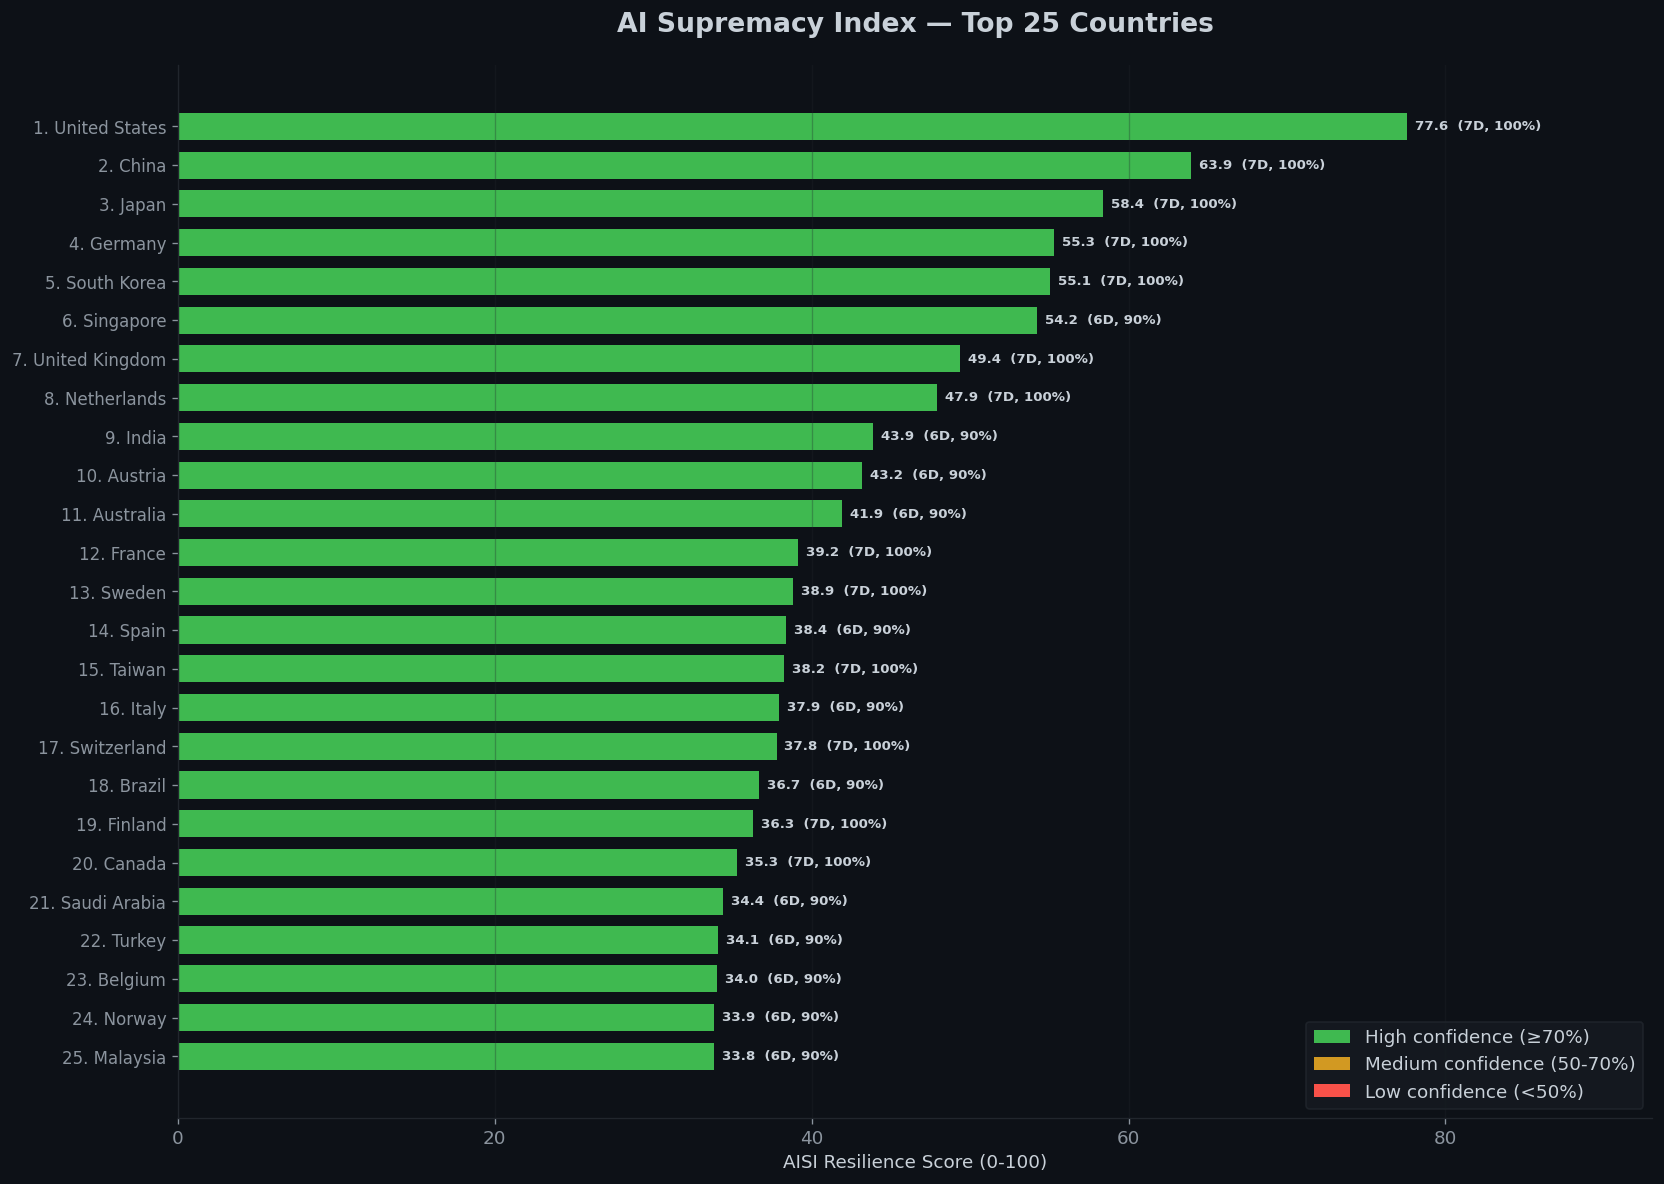

In [55]:
top25 = ranked[ranked.aisi_score.notna()].head(25).copy()

fig, ax = plt.subplots(figsize=(14, 10))

# Color by confidence
bar_colors = [C['accent2'] if cov >= 0.70 else C['accent3'] if cov >= 0.50 else C['danger']
              for cov in top25.data_coverage]

bars = ax.barh(range(len(top25)), top25['aisi_score'], color=bar_colors, height=0.7)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(
    [f"{i+1}. {row.country}" for i, (_, row) in enumerate(top25.iterrows())], fontsize=10)
ax.invert_yaxis()

for i, (_, row) in enumerate(top25.iterrows()):
    label = f'{row.aisi_score:.1f}  ({row.dims_scored:.0f}D, {row.data_coverage:.0%})'
    ax.text(row.aisi_score + 0.5, i, label, va='center', fontsize=8,
            fontweight='bold', color=C['text'])

ax.set_xlabel('AISI Resilience Score (0-100)')
ax.set_title('AI Supremacy Index — Top 25 Countries', fontsize=16, pad=20)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(0, top25['aisi_score'].max() * 1.2)

legend_elements = [
    Patch(facecolor=C['accent2'], label='High confidence (≥70%)'),
    Patch(facecolor=C['accent3'], label='Medium confidence (50-70%)'),
    Patch(facecolor=C['danger'], label='Low confidence (<50%)'),
]
ax.legend(handles=legend_elements, loc='lower right', facecolor=C['surface'], edgecolor=C['border'])

plt.tight_layout()
plt.savefig(f'{OUT}aisi_01_top25.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 13.2 Dimension Breakdown — Top 10 Countries

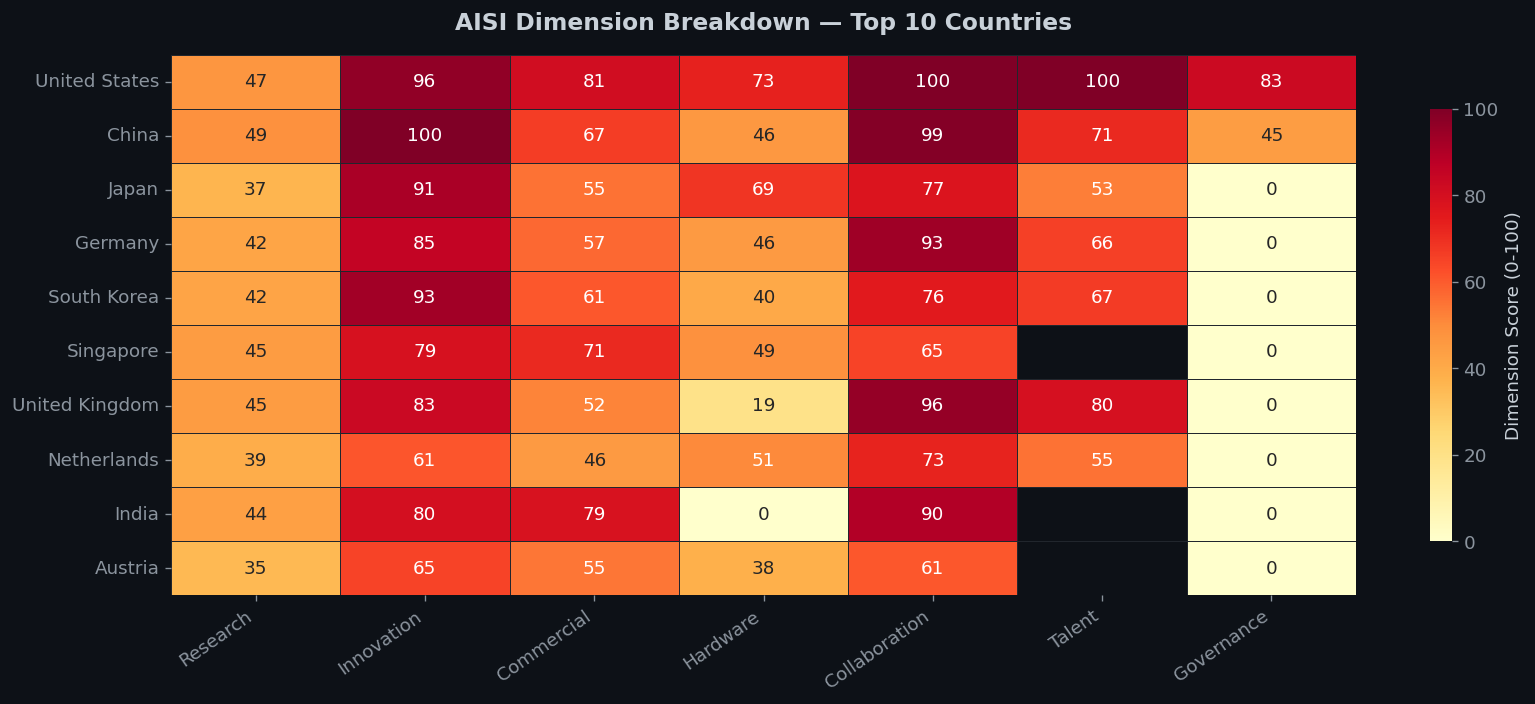

In [56]:
top10 = ranked.head(10).copy()
dim_names = {
    'dim_research_capacity': 'Research',
    'dim_innovation_output': 'Innovation',
    'dim_commercial_ecosystem': 'Commercial',
    'dim_hardware_sovereignty': 'Hardware',
    'dim_collaboration_network': 'Collaboration',
    'dim_talent_base': 'Talent',
    'dim_governance_readiness': 'Governance',
}

dim_cols_list = list(dim_names.keys())
heatmap_data = top10.set_index('country')[dim_cols_list].rename(columns=dim_names)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor=C['border'],
            cbar_kws={'label': 'Dimension Score (0-100)', 'shrink': 0.8},
            ax=ax, vmin=0, vmax=100)
ax.set_title('AISI Dimension Breakdown — Top 10 Countries', pad=15)
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.savefig(f'{OUT}aisi_02_dimension_heatmap.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 13.3 Data Coverage Distribution

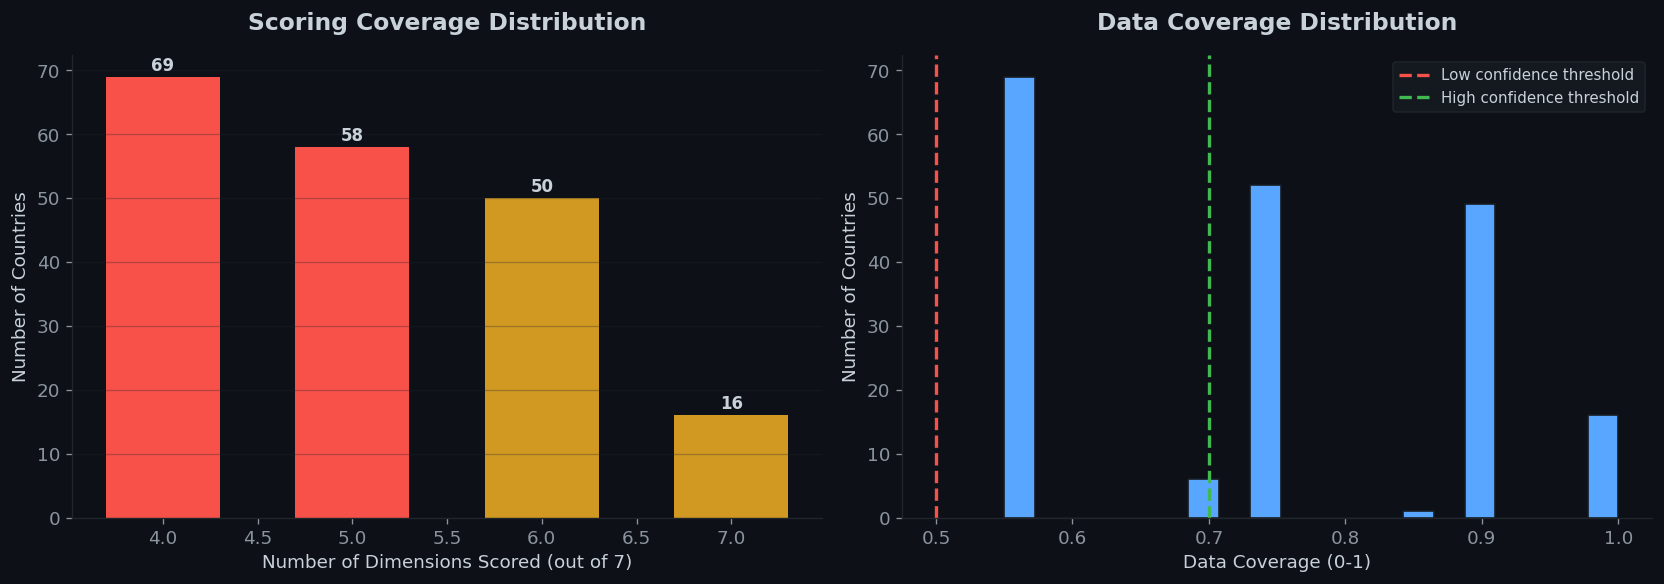

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dimensions scored histogram
dims_dist = ranked['dims_scored'].value_counts().sort_index()
colors = [C['danger'], C['danger'], C['accent3'], C['accent3'],
          C['accent'], C['accent'], C['accent2']]
ax1.bar(dims_dist.index, dims_dist.values, color=colors[:len(dims_dist)], edgecolor='none', width=0.6)
for x, y in zip(dims_dist.index, dims_dist.values):
    ax1.text(x, y + 1, str(y), ha='center', fontsize=10, fontweight='bold', color=C['text'])
ax1.set_xlabel('Number of Dimensions Scored (out of 7)')
ax1.set_ylabel('Number of Countries')
ax1.set_title('Scoring Coverage Distribution')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# Coverage percentage histogram
ax2.hist(ranked['data_coverage'].dropna(), bins=20, color=C['accent'], edgecolor=C['surface'])
ax2.axvline(0.50, color=C['danger'], linestyle='--', linewidth=2, label='Low confidence threshold')
ax2.axvline(0.70, color=C['accent2'], linestyle='--', linewidth=2, label='High confidence threshold')
ax2.set_xlabel('Data Coverage (0-1)')
ax2.set_ylabel('Number of Countries')
ax2.set_title('Data Coverage Distribution')
ax2.legend(facecolor=C['surface'], edgecolor=C['border'], fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}aisi_03_coverage.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 13.4 Score vs Coverage Scatter

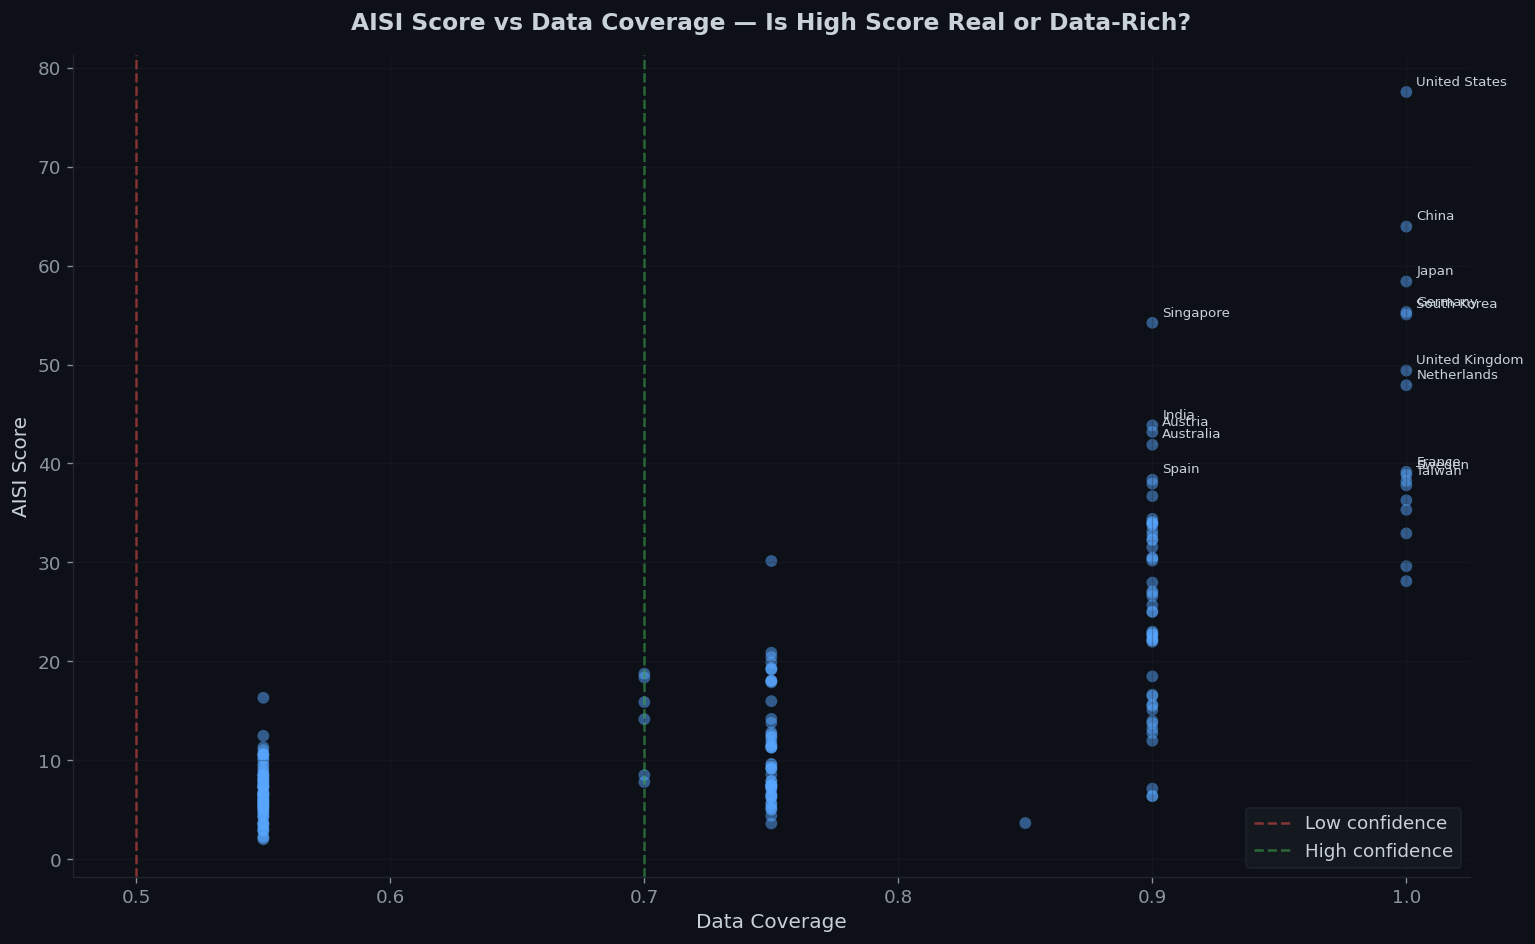

In [58]:
fig, ax = plt.subplots(figsize=(13, 8))

valid = ranked[ranked.aisi_score.notna()].copy()
scatter = ax.scatter(
    valid['data_coverage'], valid['aisi_score'],
    s=50, c=C['accent'], alpha=0.5, edgecolors='none'
)

# Label top 15
for _, row in valid.head(15).iterrows():
    ax.annotate(row.country, (row.data_coverage, row.aisi_score),
        xytext=(6, 4), textcoords='offset points', fontsize=8, color=C['text'],
        arrowprops=dict(arrowstyle='-', color=C['text_dim'], alpha=0.3))

ax.axvline(0.50, color=C['danger'], linestyle='--', alpha=0.5, label='Low confidence')
ax.axvline(0.70, color=C['accent2'], linestyle='--', alpha=0.5, label='High confidence')

ax.set_xlabel('Data Coverage', fontsize=12)
ax.set_ylabel('AISI Score', fontsize=12)
ax.set_title('AISI Score vs Data Coverage — Is High Score Real or Data-Rich?', pad=15)
ax.legend(facecolor=C['surface'], edgecolor=C['border'])
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}aisi_04_score_vs_coverage.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 13.5 Dimension Weight Contribution — Top 10

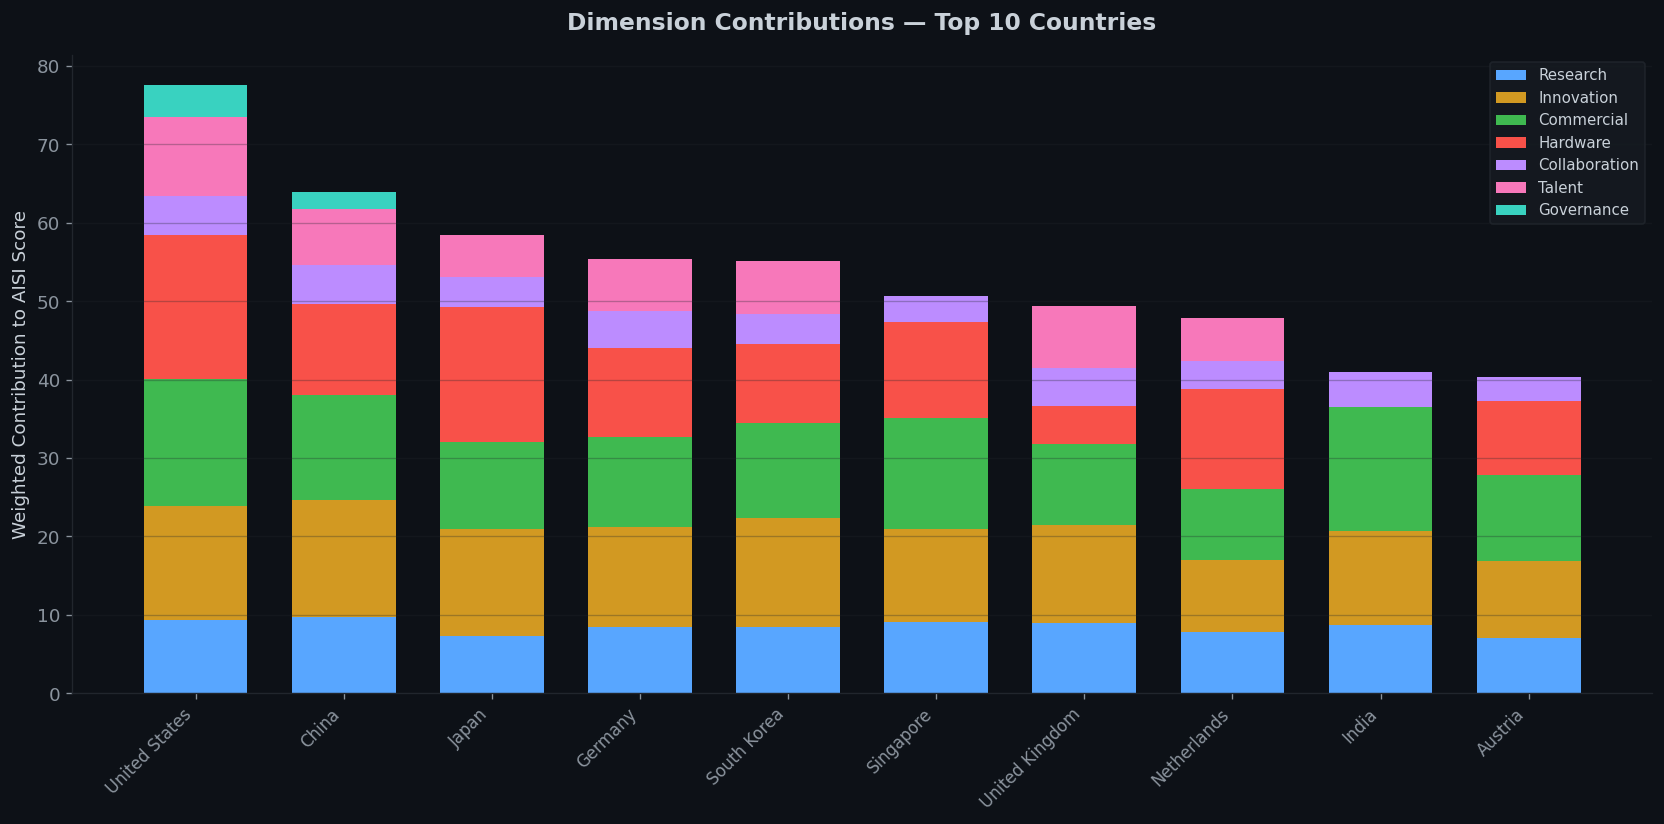

In [59]:
# Show how much each dimension contributes to the final score
top10_detail = ranked.head(10).copy()

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top10_detail))
bottom = np.zeros(len(top10_detail))

dim_colors = {
    'dim_hardware_sovereignty': C['danger'],
    'dim_research_capacity': C['accent'],
    'dim_commercial_ecosystem': C['accent2'],
    'dim_innovation_output': C['accent3'],
    'dim_talent_base': C['accent4'],
    'dim_collaboration_network': C['accent5'],
    'dim_governance_readiness': C['cyan'],
}

for dim_col, weight in dim_weight_map.items():
    vals = top10_detail[dim_col].fillna(0).values * weight
    ax.bar(x, vals, bottom=bottom, width=0.7,
           color=dim_colors[dim_col], label=dim_names[dim_col], edgecolor='none')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(top10_detail['country'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Weighted Contribution to AISI Score')
ax.set_title('Dimension Contributions — Top 10 Countries', pad=15)
ax.legend(loc='upper right', facecolor=C['surface'], edgecolor=C['border'], fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}aisi_05_contributions.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

---
## 14. Save Final Output

In [60]:
# ── Select and order output columns ──
output_cols = [
    'country', 'aisi_score', 'data_coverage', 'dims_scored', 'low_confidence',
    'hq_attribution_flag',
    'dim_research_capacity', 'dim_innovation_output', 'dim_commercial_ecosystem',
    'dim_hardware_sovereignty', 'dim_collaboration_network',
    'dim_talent_base', 'dim_governance_readiness',
    'talent_tier', 'innovation_output_latest_year',
    'has_publications', 'has_patents', 'has_investment',
    'has_semiconductor', 'has_collaboration', 'has_parat',
    'has_governance', 'has_workforce',
]

# Keep only columns that exist

output_cols = [c for c in output_cols if c in aisi.columns]

output = aisi[output_cols].sort_values('aisi_score', ascending=False).reset_index(drop=True)
output.index = output.index + 1
output.index.name = 'rank'

# Save
output.to_csv(f'{OUT}AISI_Final_Rankings.csv')
print(f'✅ Saved: AISI_Final_Rankings.csv')
print(f'   {output.shape[0]} countries × {output.shape[1]} columns')

# Also save high-confidence subset
high_conf_output = output[output['data_coverage'] >= 0.50]
high_conf_output.to_csv(f'{OUT}AISI_High_Confidence_Rankings.csv')
print(f'✅ Saved: AISI_High_Confidence_Rankings.csv')
print(f'   {high_conf_output.shape[0]} countries with ≥50% data coverage')

✅ Saved: AISI_Final_Rankings.csv
   193 countries × 23 columns
✅ Saved: AISI_High_Confidence_Rankings.csv
   193 countries with ≥50% data coverage


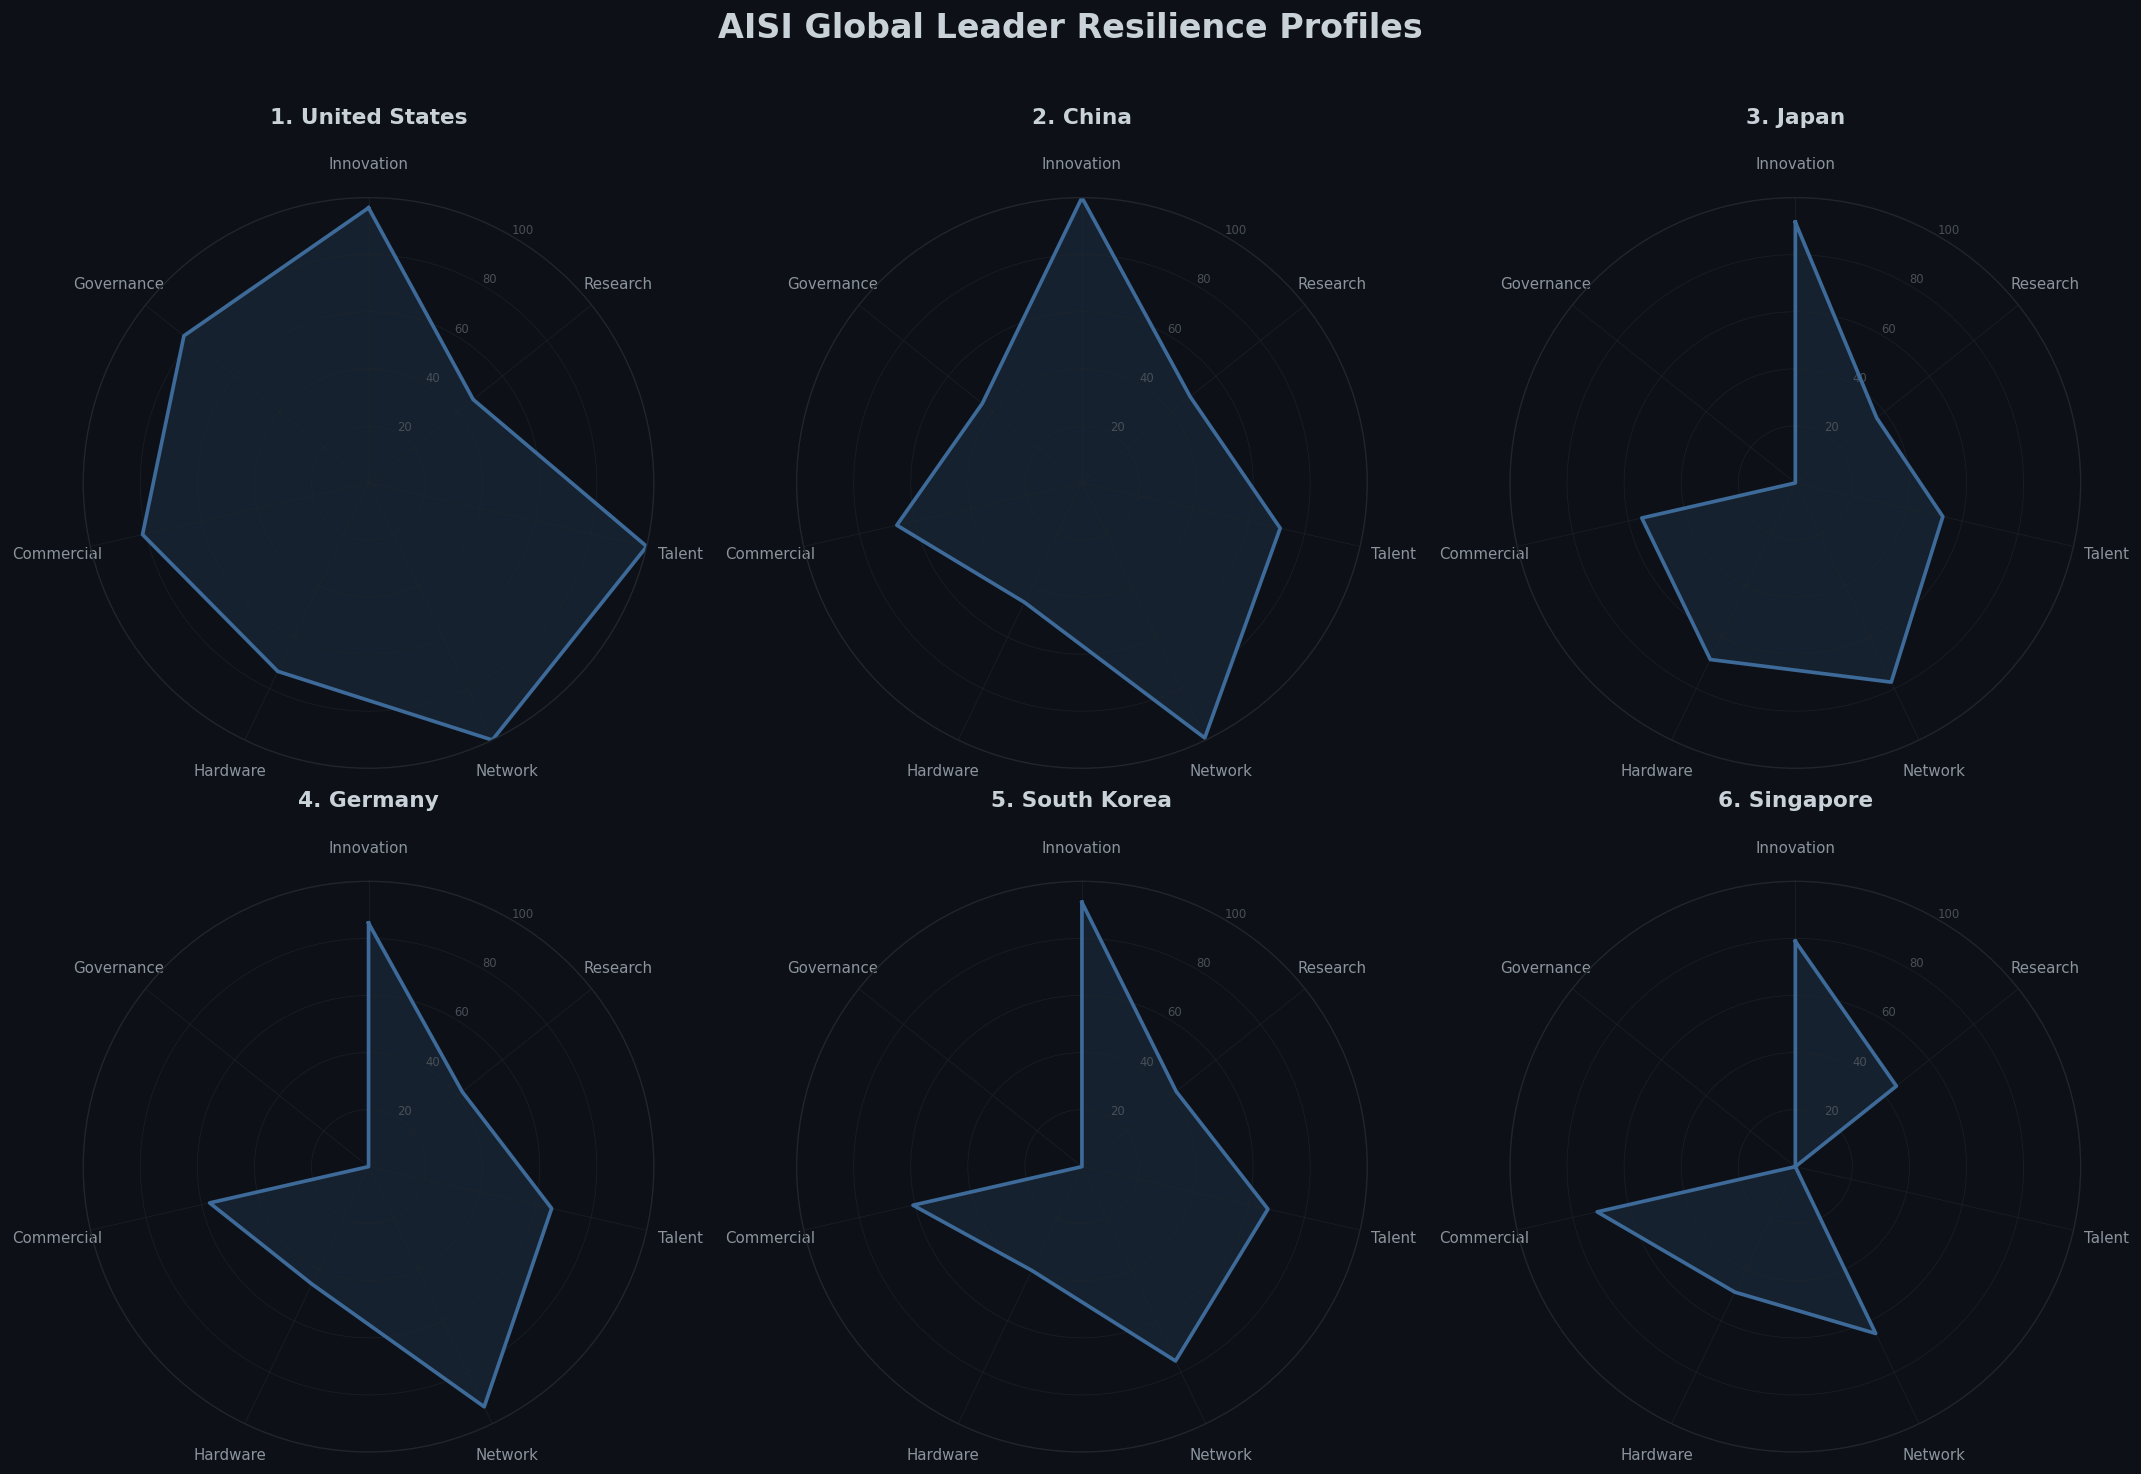

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Load rankings and extract top 6 ──
df = pd.read_csv('/Users/shadowclone/Documents/aisi/aisi/AISI_Final_Rankings.csv', index_col=0)
top6 = df.head(6).copy()

dimensions = ['Innovation', 'Research', 'Talent', 'Network', 'Hardware', 'Commercial', 'Governance']
dim_cols = [
    'dim_innovation_output', 'dim_research_capacity', 'dim_talent_base',
    'dim_collaboration_network', 'dim_hardware_sovereignty',
    'dim_commercial_ecosystem', 'dim_governance_readiness',
]

# Build dictionary: {label: [scores]}
countries = {}
for rank, (_, row) in enumerate(top6.iterrows(), 1):
    label = f"{rank}. {row['country']}"
    scores = [row[col] if pd.notna(row[col]) else 0 for col in dim_cols]
    countries[label] = scores

# ── Radar chart ──
n_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('AISI Global Leader Resilience Profiles', fontsize=20,
             fontweight='bold', color='#C9D1D9', y=1.02)

for ax, (country, scores) in zip(axes.flat, countries.items()):
    values = scores + scores[:1]

    ax.set_facecolor('#0D1117')
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rlabel_position(30)
    ax.set_rticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7, color='#484F58')
    ax.set_ylim(0, 100)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dimensions, fontsize=9, color='#8B949E')

    ax.spines['polar'].set_color('#21262D')
    ax.xaxis.grid(True, color='#21262D', linewidth=0.5)
    ax.yaxis.grid(True, color='#21262D', linewidth=0.5)
    ax.tick_params(axis='x', pad=10)

    ax.plot(angles, values, color='#3D6A99', linewidth=2.2)
    ax.fill(angles, values, color='#3D6A99', alpha=0.18)

    ax.set_title(country, fontsize=13, fontweight='bold', color='#C9D1D9', pad=20)

plt.tight_layout()
plt.savefig('/Users/shadowclone/Documents/aisi/aisi_radar_profiles.png',
            bbox_inches='tight', facecolor='#0D1117', dpi=150)
plt.show()

In [62]:
# ── AISI v2: Without Governance Readiness ──
WEIGHTS_V2 = {
    'dim_research_capacity': 0.22,      # was 0.20, absorb +2%
    'dim_innovation_output': 0.18,       # unchanged
    'dim_commercial_ecosystem': 0.22,    # was 0.20, absorb +2%
    'dim_hardware_sovereignty': 0.23,    # was 0.22, absorb +1%
    'dim_collaboration_network': 0.05,   # unchanged
    'dim_talent_base': 0.10,             # unchanged
}

def compute_aisi_v2(row):
    numerator = 0
    denominator = 0
    dims_used = 0
    for dim_col, weight in WEIGHTS_V2.items():
        score = row[dim_col]
        if pd.notna(score):
            numerator += score * weight
            denominator += weight
            dims_used += 1
    if denominator == 0:
        return np.nan, 0, dims_used
    return numerator / denominator, denominator / sum(WEIGHTS_V2.values()), dims_used

results_v2 = aisi.apply(compute_aisi_v2, axis=1, result_type='expand')
aisi['aisi_score_v2_raw'] = results_v2[0]
aisi['data_coverage_v2'] = results_v2[1]
aisi['dims_scored_v2'] = results_v2[2].astype(int)

# Apply breadth factor (now out of 6 dimensions instead of 7)
aisi['breadth_factor_v2'] = 0.75 + 0.25 * (aisi['dims_scored_v2'] / 6)
aisi['aisi_score_v2'] = aisi['aisi_score_v2_raw'] * aisi['breadth_factor_v2']

# Save
v2_cols = ['country', 'aisi_score_v2', 'aisi_score_v2_raw', 'data_coverage_v2', 'dims_scored_v2',
           'dim_research_capacity', 'dim_innovation_output', 'dim_commercial_ecosystem',
           'dim_hardware_sovereignty', 'dim_collaboration_network', 'dim_talent_base']
v2_output = aisi[v2_cols].sort_values('aisi_score_v2', ascending=False).reset_index(drop=True)
v2_output.index = v2_output.index + 1
v2_output.index.name = 'rank'
v2_output.to_csv(f'{OUT}AISI_Final_Rankings_v2_no_governance.csv')
print(f'✅ Saved: AISI_Final_Rankings_v2_no_governance.csv')
print(v2_output.head(15).to_string(float_format='%.1f'))

✅ Saved: AISI_Final_Rankings_v2_no_governance.csv
             country  aisi_score_v2  aisi_score_v2_raw  data_coverage_v2  dims_scored_v2  dim_research_capacity  dim_innovation_output  dim_commercial_ecosystem  dim_hardware_sovereignty  dim_collaboration_network  dim_talent_base
rank                                                                                                                                                                                                                                  
1      United States           77.4               77.4               1.0               6                   46.9                   96.4                      81.2                      73.3                      100.0            100.0
2              China           66.1               66.1               1.0               6                   48.5                  100.0                      66.6                      46.4                       99.2             71.3
3              Japan      

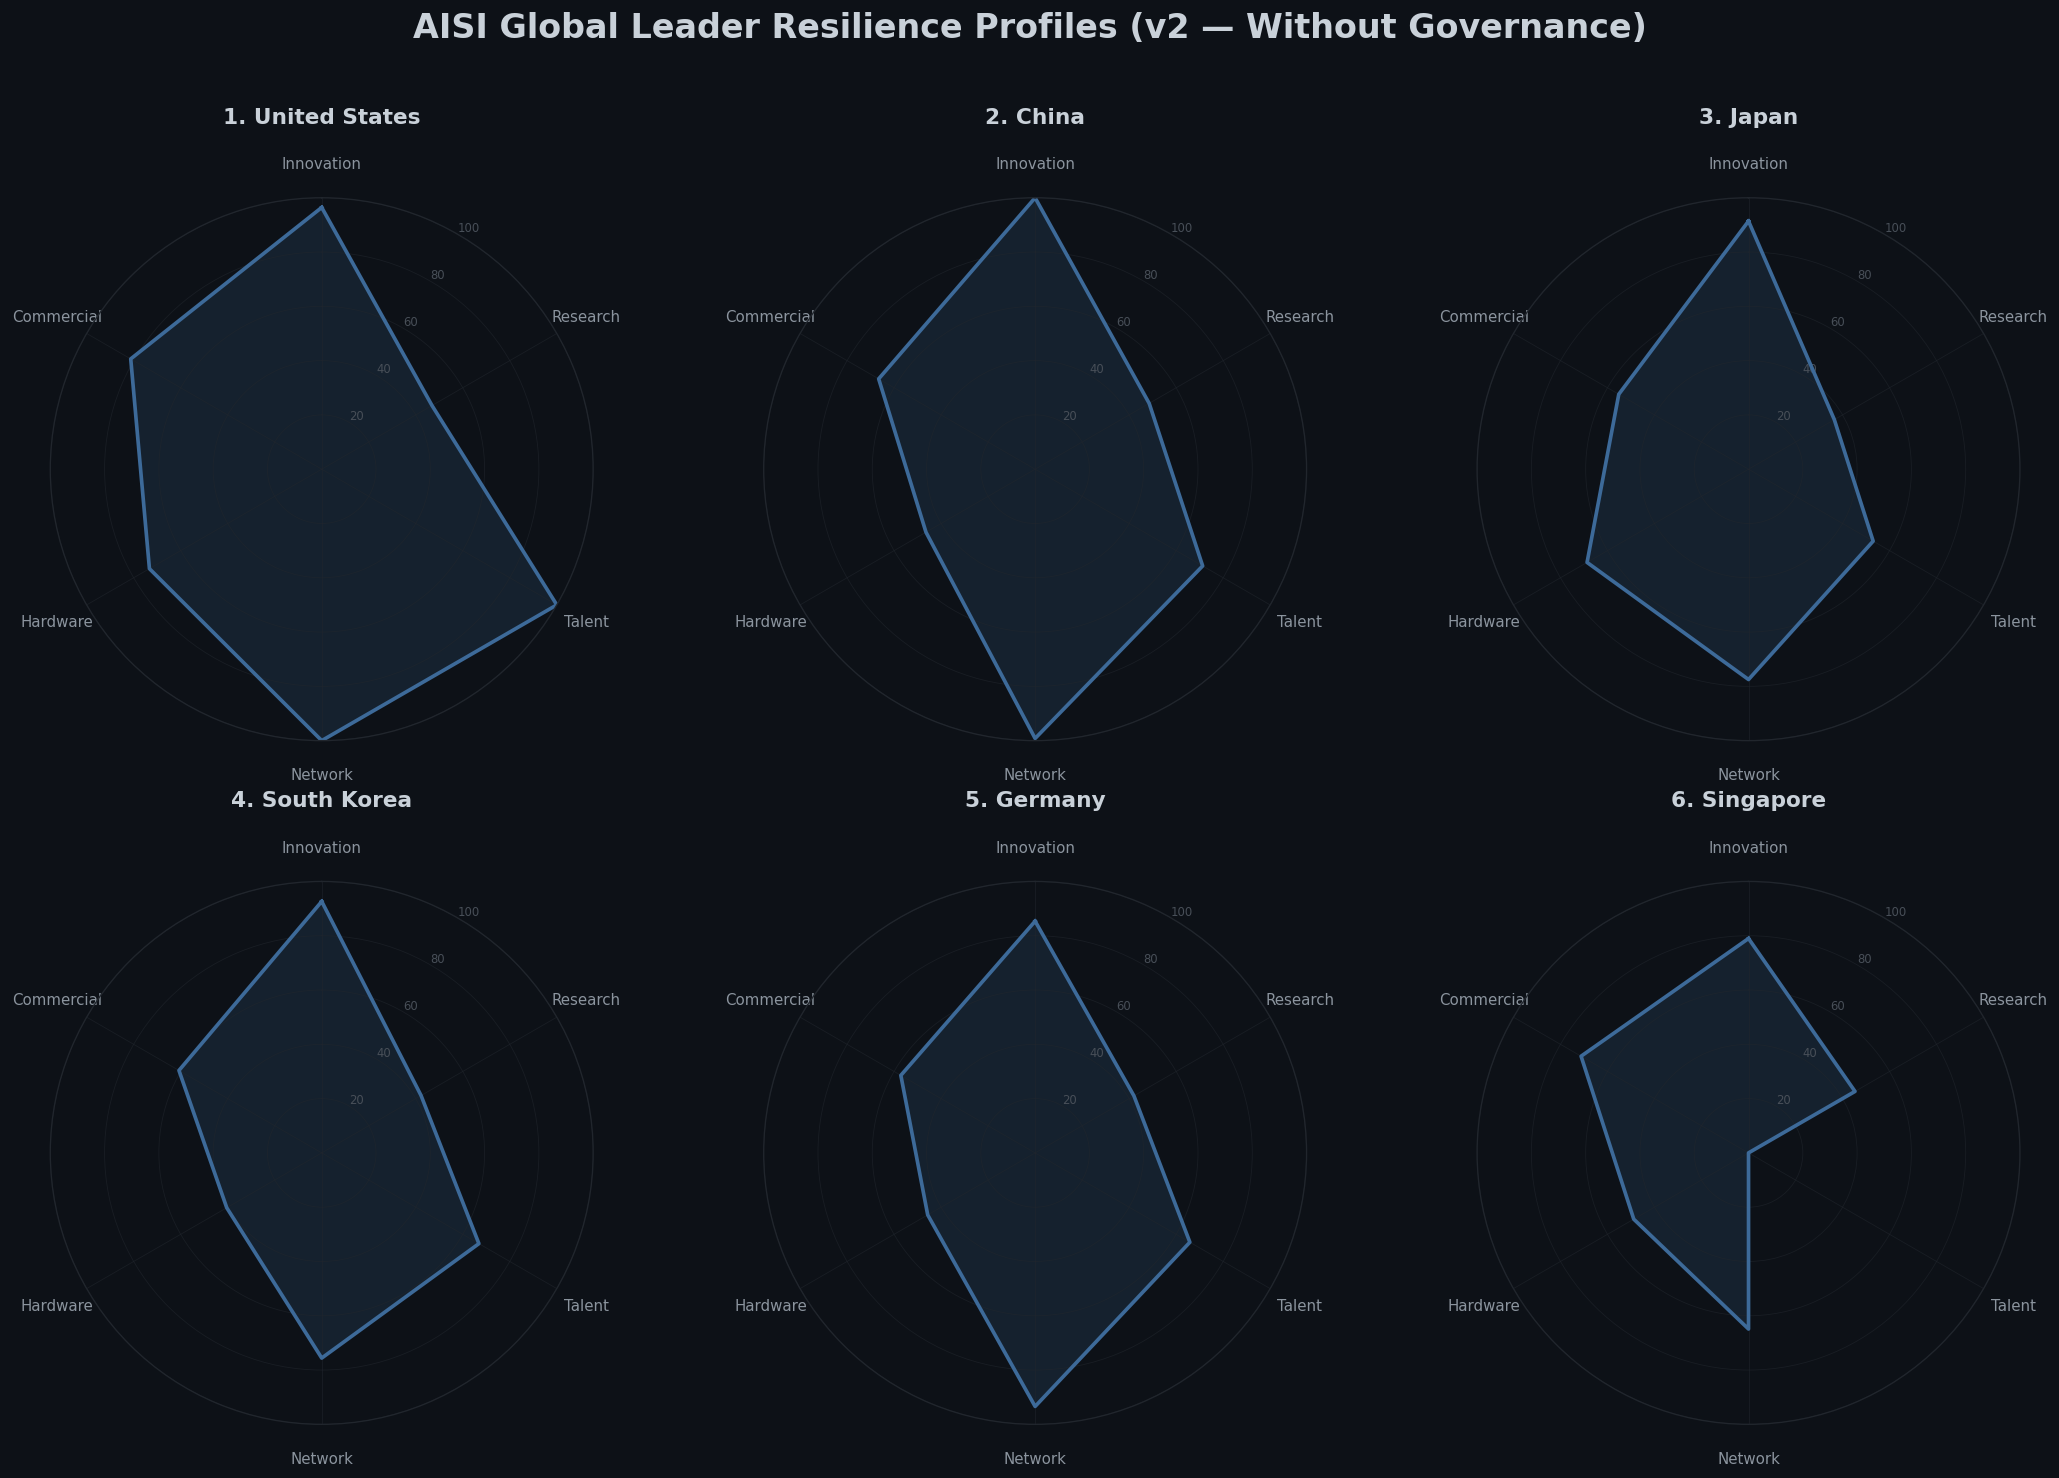

In [63]:
# ── Radar Chart for AISI v2 (No Governance) ──
df_v2 = pd.read_csv(f'{OUT}AISI_Final_Rankings_v2_no_governance.csv', index_col=0)
top6 = df_v2.head(6).copy()

dimensions = ['Innovation', 'Research', 'Talent', 'Network', 'Hardware', 'Commercial']
dim_cols = [
    'dim_innovation_output', 'dim_research_capacity', 'dim_talent_base',
    'dim_collaboration_network', 'dim_hardware_sovereignty', 'dim_commercial_ecosystem',
]

countries = {}
for rank, (_, row) in enumerate(top6.iterrows(), 1):
    label = f"{rank}. {row['country']}"
    scores = [row[col] if pd.notna(row[col]) else 0 for col in dim_cols]
    countries[label] = scores

n_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('AISI Global Leader Resilience Profiles (v2 — Without Governance)',
             fontsize=20, fontweight='bold', color='#C9D1D9', y=1.02)

for ax, (country, scores) in zip(axes.flat, countries.items()):
    values = scores + scores[:1]

    ax.set_facecolor('#0D1117')
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rlabel_position(30)
    ax.set_rticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7, color='#484F58')
    ax.set_ylim(0, 100)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dimensions, fontsize=9, color='#8B949E')

    ax.spines['polar'].set_color('#21262D')
    ax.xaxis.grid(True, color='#21262D', linewidth=0.5)
    ax.yaxis.grid(True, color='#21262D', linewidth=0.5)
    ax.tick_params(axis='x', pad=10)

    ax.plot(angles, values, color='#3D6A99', linewidth=2.2)
    ax.fill(angles, values, color='#3D6A99', alpha=0.18)

    ax.set_title(country, fontsize=13, fontweight='bold', color='#C9D1D9', pad=20)

plt.tight_layout()
plt.savefig(f'{OUT}aisi_radar_profiles_v2.png', bbox_inches='tight', facecolor='#0D1117', dpi=150)
plt.show()

---
## Done ✓

**Outputs:**
- `AISI_Final_Rankings.csv` — Complete rankings for all countries
- `AISI_High_Confidence_Rankings.csv` — Filtered to ≥50% data coverage
- 5 visualization PNGs

**Pipeline summary:**
1. Harmonized country names across 5 datasets using explicit lookup table
2. Computed 7 dimension scores with sub-component weighting and missing-data redistribution
3. Applied coverage-weighted composite to produce final AISI scores
4. Flagged low-confidence countries, HQ attribution concerns, and innovation data lag

**Methodology version:** v3 (post-data audit)

**Key methodological safeguards applied:**
- Log(1+x) on all skewed metrics (publications, patents, investment)
- Complete-year filtering on all time-series data
- Citation window lagged to 2021-2023 (avoiding incomplete recent data)
- Patent data flagged as 2015-2020 only (5-year lag)
- PARAT sub-components redistributed for countries without PARAT coverage
- Governance dimension limited to individually-mappable countries only
- Coverage-weighted composite distinguishes 'low capability' from 'no data'